## Downloading dataset from Kaggle using CLI

In [ ]:
!which python

/home/midori/Desktop/Machine-Learning/venv/bin/python


### Downloading dataset from kaggle

In [ ]:
#!/bin/bash
!kaggle datasets download -d vjchoudhary7/customer-segmentation-tutorial-in-python -p ~/Desktop/Machine-Learning/Notebook/Unsupervised/Kmeans/Data/

Dataset URL: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python
License(s): other
  0%|                                               | 0.00/1.55k [00:00<?, ?B/s]
100%|██████████████████████████████████████| 1.55k/1.55k [00:00<00:00, 7.37MB/s]


### Extracting zip and proving the file location

In [ ]:
# extracting the compessed Dataset
from zipfile import ZipFile
from pathlib import Path

zip_path = Path.home() / "Desktop/Machine-Learning/Notebook/Unsupervised/Kmeans/Data/customer_purchase.zip"
extract_dir = Path.home() / "Desktop/Machine-Learning/Notebook/Unsupervised/Kmeans/Data/"

with ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("Dataset extracted to:", extract_dir)

Dataset extracted to: /home/midori/Desktop/Machine-Learning/Notebook/Unsupervised/Kmeans/Data


## Analysis

In [1]:
# dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
# loading the dataset
dataset = pd.read_csv('./Data/Mall_Customers.csv')
# Display first few rows
print("First 5 rows of dataset:")
dataset.head()

First 5 rows of dataset:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
dataset.shape

(200, 6)

In [ ]:
dataset.columns.size

6

In [ ]:
dataset.size

1200

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
 5   Cluster                 200 non-null    int32 
dtypes: int32(1), int64(4), object(1)
memory usage: 8.7+ KB


In [ ]:
dataset.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Cluster
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000,1.790000
std,57.879185,13.969007,26.264721,25.823522,1.293936
min,1.000000,18.000000,15.000000,1.000000,0.000000
25%,50.750000,28.750000,41.500000,34.750000,0.000000
50%,100.500000,36.000000,61.500000,50.000000,2.000000
75%,150.250000,49.000000,78.000000,73.000000,3.000000
max,200.000000,70.000000,137.000000,99.000000,4.000000


In [3]:
# scaling the featues using StandardScalar
X = dataset[['Annual Income (k$)','Annual Income (k$)']]

In [6]:
scaler = StandardScaler()

scaler.fit(X)        # learn mean and std
X = scaler.transform(X)   # apply scaling

In [ ]:
#  Apply K-Means Clustering
kmeans = KMeans(n_clusters=5, random_state=42)
# That means the algorithm will create 5 clusters.
# Internally, sklearn labels clusters as:
# 0, 1, 2, 3, 4
# 

kmeans.fit(X)
clusters = kmeans.predict(X)
# Each row gets assigned the index of the nearest centroid.
# Cluster = 2
# That customer is closest to centroid #2
# It is just an index number of the centroid array.

In [8]:

# Add cluster labels to dataset
dataset['Cluster'] = clusters

# 6. Get Centroids
centroids = kmeans.cluster_centers_

In [12]:
centroids

array([[-0.51170524, -0.51170524],
       [ 1.23821628,  1.23821628],
       [-1.40351   , -1.40351   ],
       [ 0.35000335,  0.35000335],
       [ 2.42146859,  2.42146859]])

In [9]:
dataset.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,2
2,3,Female,20,16,6,2
3,4,Female,23,16,77,2
4,5,Female,31,17,40,2


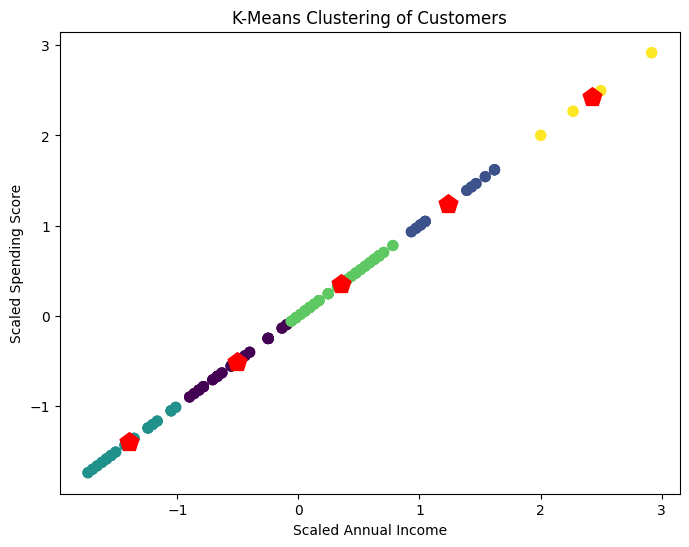

In [15]:
plt.figure(figsize=(8,6))

plt.scatter(X[:,0], X[:,1], c=clusters, cmap='viridis', s=50)
# alternative of 'viridis' are 'plasma', 'cool', 'rainbow'

# Plot centroids
plt.scatter(centroids[:,0], centroids[:,1], 
            c='red', s=200, marker='p')

plt.xlabel("Scaled Annual Income")
plt.ylabel("Scaled Spending Score")
plt.title("K-Means Clustering of Customers")
plt.show()

In [23]:
print("\nCluster-wise Mean Values:")
cluster_analysis = dataset.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()
print(cluster_analysis)

# Optional: Count customers in each cluster
print("\nNumber of customers in each cluster:")
print(dataset['Cluster'].value_counts())


Cluster-wise Mean Values:
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 47.153846               51.076923
1                 93.000000               50.928571
2                 23.789474               49.210526
3                 69.729730               49.878378
4                124.000000               49.625000

Number of customers in each cluster:
Cluster
3    74
0    52
2    38
1    28
4     8
Name: count, dtype: int64


In [24]:
for i in range(5):
    income = cluster_analysis.iloc[i][0]
    spending = cluster_analysis.iloc[i][1]
    
    print(f"\nCluster {i} Analysis:")
    
    if income > 60 and spending > 60:
        print("-> High Income, High Spending (Premium Customers)")
    elif income < 40 and spending < 40:
        print("-> Low Income, Low Spending (Budget Customers)")
    elif income > 60 and spending < 40:
        print("-> High Income, Low Spending (Conservative Customers)")
    elif income < 40 and spending > 60:
        print("-> Low Income, High Spending (Impulsive Buyers)")
    else:
        print("-> Medium Income & Medium Spending (Average Customers)")


Cluster 0 Analysis:
-> Medium Income & Medium Spending (Average Customers)

Cluster 1 Analysis:
-> Medium Income & Medium Spending (Average Customers)

Cluster 2 Analysis:
-> Medium Income & Medium Spending (Average Customers)

Cluster 3 Analysis:
-> Medium Income & Medium Spending (Average Customers)

Cluster 4 Analysis:
-> Medium Income & Medium Spending (Average Customers)


/tmp/ipykernel_13109/2862515353.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  income = cluster_analysis.iloc[i][0]
/tmp/ipykernel_13109/2862515353.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  spending = cluster_analysis.iloc[i][1]
